<img src='../_images/logos/feature-engine.webp' width="400px">

# Feature-engine - Topic 02 - Handle Missing Data

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%202%20-%20Unit%20Objective.png"> 

## Topic Objectives

* Learn how to handle Missing Data on numerical and categorical data.

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%204%20-%20Import%20Package%20for%20Learning.png"> 

## Import Packages for Learning

And load our typical packages.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
from sklearn.pipeline import Pipeline

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

## Handle Missing Data

Feature-engine imputes missing data with values learned from the data or arbitrary values set by the user, either for numerical or categorical variables. We will study:
* Mean Median Imputer
* Arbitrary Number Imputer
* Categorical Imputer
* Drop Missing Data

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png">

#### Mean Median Imputer

It replaces missing data with the mean or median value of the variable. It works only with numerical variables. The documentation link is [here](https://feature-engine.trainindata.com/en/latest/user_guide/imputation/MeanMedianImputer.html)


* Parse a list of variables to be imputed. Alternatively, this imputer can automatically select all variables of type numeric.
* The imputer first calculates the mean/median values of the variables (with the fit method). Then it replaces the missing data with the estimated value (with the transform method).

In [2]:
from feature_engine.imputation import MeanMedianImputer

How do you know if you should impute the mean or the median?
* You should assess the numerical distribution plot. If it is normally distributed (bell curve shape), you can replace missing values using ``mean``. Otherwise, replace using ``median``.

Let's load the dataset, which contains information on transactions made by customers through an online retail platform. The dataset includes data on the products that were purchased, the quantity of each product, the date and time of each transaction, the price of each product, the unique identifier for each customer who made a purchase, and the country where each customer is located.

In [3]:
df = pd.read_csv('data/Online_Retail.csv')
df = df.sample(frac=0.5, random_state=5)
df = df.astype({'CustomerID':'object'})
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2519,547809,21430,SET/3 RED GINGHAM ROSE STORAGE BOX,1.0,3/25/11 13:54,3.75,12748.0,United Kingdom
10237,548516,84991,60 TEATIME FAIRY CAKE CASES,5.0,3/31/11 16:28,1.25,NaN,United Kingdom
6949,548194,22499,WOODEN UNION JACK BUNTING,2.0,3/29/11 15:30,12.46,NaN,United Kingdom
5415,547987,20724,RED RETROSPOT CHARLOTTE BAG,10.0,3/29/11 9:11,0.85,17428.0,United Kingdom
125,547568,22382,LUNCH BAG SPACEBOY DESIGN,10.0,3/24/11 9:50,1.65,13341.0,NaN
...,...,...,...,...,...,...,...,...
895,C547661,22356,CHARLOTTE BAG PINK POLKADOT,-2.0,3/24/11 13:09,0.85,13736.0,United Kingdom
5088,547964,35471D,SET OF 3 BIRD LIGHT PINK FEATHER,3.0,3/28/11 15:45,2.46,NaN,United Kingdom
1608,547715,21238,RED RETROSPOT CUP,8.0,3/25/11 8:50,0.85,12520.0,Germany
6269,548165,22659,LUNCH BOX I LOVE LONDON,1.0,3/29/11 13:44,2.46,NaN,United Kingdom


Let's check missing data levels with `.isnull().sum()`

In [4]:
df.isnull().sum()

InvoiceNo         0
StockCode         1
Description      38
Quantity          2
InvoiceDate       0
UnitPrice         3
CustomerID     1249
Country           1
dtype: int64

We assess the distribution. We will replace the values with the median. (Hint: Each column has 5342 values; thus, it can take some time to calculate distributions. Also, we cut our values to -50 : 50 range by `df.query()`. We will delve into handling outliers in future topics).

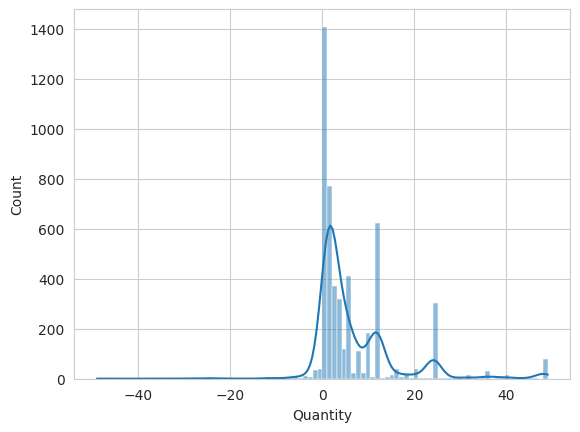

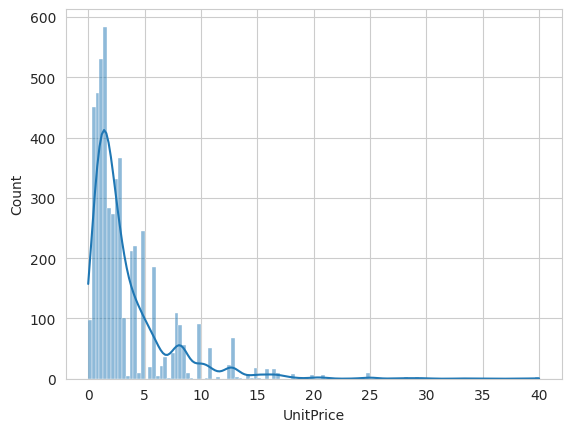

In [5]:
sns.set_style('whitegrid')
for col in ['Quantity' , 'UnitPrice']:
  sns.histplot(data=df.query('Quantity > -50 & UnitPrice > -50 & Quantity < 50 & UnitPrice < 50'), x=col, kde=True)
  plt.show()
  print('\n')

We load and set the transformer. The arguments are:
* imputation_method: either mean or median
* variables: list of numerical variables to apply the method to. If you don't pass in anything here, the transformer will consider all numerical variables.

In [6]:
from feature_engine.imputation import MeanMedianImputer
imputer = MeanMedianImputer(imputation_method='median',
                            variables=['Quantity' , 'UnitPrice'])

We use the `.fit()` method so the transformer can learn the median values from the selected variables. The argument is the dataset you are interested to learn from.

In [7]:
imputer.fit(df)

,imputation_method,'median'
,variables,"['Quantity', 'UnitPrice']"


As a confirmation step, let's check the learned values with the attribute `.imputer_dict_`

In [8]:
imputer.imputer_dict_

{'Quantity': 3.0, 'UnitPrice': 2.1}

We now transform the data, which means we replace the missing data of each variable according to its respective learned median value. We use `.transform()` method. The argument is the dataset you want to transform.

In [9]:
df = imputer.transform(df)

Check the output, it is a DataFrame.
* At first, we may think this is a minor detail; however, other libraries for feature engineering, like scikit-learn, return, as an array, a ``.transform()`` command when doing a data transformation.

In [10]:
print(type(df))
df

<class 'pandas.core.frame.DataFrame'>


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2519,547809,21430,SET/3 RED GINGHAM ROSE STORAGE BOX,1.0,3/25/11 13:54,3.75,12748.0,United Kingdom
10237,548516,84991,60 TEATIME FAIRY CAKE CASES,5.0,3/31/11 16:28,1.25,NaN,United Kingdom
6949,548194,22499,WOODEN UNION JACK BUNTING,2.0,3/29/11 15:30,12.46,NaN,United Kingdom
5415,547987,20724,RED RETROSPOT CHARLOTTE BAG,10.0,3/29/11 9:11,0.85,17428.0,United Kingdom
125,547568,22382,LUNCH BAG SPACEBOY DESIGN,10.0,3/24/11 9:50,1.65,13341.0,NaN
...,...,...,...,...,...,...,...,...
895,C547661,22356,CHARLOTTE BAG PINK POLKADOT,-2.0,3/24/11 13:09,0.85,13736.0,United Kingdom
5088,547964,35471D,SET OF 3 BIRD LIGHT PINK FEATHER,3.0,3/28/11 15:45,2.46,NaN,United Kingdom
1608,547715,21238,RED RETROSPOT CUP,8.0,3/25/11 8:50,0.85,12520.0,Germany
6269,548165,22659,LUNCH BOX I LOVE LONDON,1.0,3/29/11 13:44,2.46,NaN,United Kingdom


Let's check missing levels on `['Quantity', 'UnitPrice']`. They were replaced with median values.

In [11]:
df.isnull().sum()

InvoiceNo         0
StockCode         1
Description      38
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID     1249
Country           1
dtype: int64

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

Let's use an example where we arrange a transformer in a pipeline. We will use this approach from now on. 
* First, we reload the dataset with missing data


In [12]:
df = pd.read_csv('data/Online_Retail.csv')
df = df.sample(frac=0.5, random_state=5)
df = df.astype({'CustomerID':'object'})
df.isnull().sum()

InvoiceNo         0
StockCode         1
Description      38
Quantity          2
InvoiceDate       0
UnitPrice         3
CustomerID     1249
Country           1
dtype: int64

We set the pipeline in one step. We name it 'median'. Then we use the `MeanMedianImputer()` and the arguments we saw earlier.

In [13]:
pipeline = Pipeline([
      ( 'median',  MeanMedianImputer(imputation_method='median',
                                     variables=['Quantity' , 'UnitPrice']) )
])
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('median', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,imputation_method,'median'
,variables,"['Quantity', 'UnitPrice']"


We fit the pipeline. That means we will execute all the tasks in the pipeline.
* In this example, the pipeline has one step that learns the median value from the selected variables.

In [14]:
pipeline.fit(df)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('median', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,imputation_method,'median'
,variables,"['Quantity', 'UnitPrice']"


We then transform the dataset.

In [15]:
df = pipeline.transform(df)

And check for missing data.

In [16]:
df.isnull().sum()

InvoiceNo         0
StockCode         1
Description      38
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID     1249
Country           1
dtype: int64

If we want to check the learned values from the median imputed, we have to assess the step. Using bracket notation, we write the step name.

In [17]:
pipeline['median']

,imputation_method,'median'
,variables,"['Quantity', 'UnitPrice']"


We then use the respective attribute from the transformer, in this case, `.imputer_dict_`

In [18]:
pipeline['median'].imputer_dict_

{'Quantity': 3.0, 'UnitPrice': 2.1}

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

#### Arbitrary Number

It replaces missing data in numerical variables with an arbitrary number determined by the user. The function documentation is [here](https://feature-engine.trainindata.com/en/latest/user_guide/imputation/ArbitraryNumberImputer.html)
* The arguments are the variables and the number to be imputed.

In [19]:
from feature_engine.imputation import ArbitraryNumberImputer

Let's use the same 'Online_Retail' dataset and check missing data levels.

In [20]:
df = pd.read_csv('data/Online_Retail.csv')
df = df.sample(frac=0.5, random_state=5)
df = df.astype({'CustomerID':'object'})
df.isnull().sum()

InvoiceNo         0
StockCode         1
Description      38
Quantity          2
InvoiceDate       0
UnitPrice         3
CustomerID     1249
Country           1
dtype: int64

We set the pipeline. Imagine you conducted the same data analysis as before and decided (with no basis) you want to impute`-100` where `Quantity`, and `-500` for the remaining numerical variables with missing data.
* The values we chose here are arbitrary. In a project, this imputation can relate to a particular business context. For example, imagine if a survey showed that small orders often have missing values in `Quantity`, meaning 1 (small order quantity) is the best imputer in such a scenario.

In [21]:
pipeline = Pipeline([
      ( 'Quantity',  ArbitraryNumberImputer(arbitrary_number=-100,
                                                  variables=['Quantity']) ),

      ( 'other_variables',  ArbitraryNumberImputer(arbitrary_number=-500,
                                                   variables=['UnitPrice']) )

])
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Quantity', ...), ('other_variables', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,arbitrary_number,-100
,variables,['Quantity']
,imputer_dict,None
,arbitrary_number,-500
,variables,['UnitPrice']
,imputer_dict,None


We fit the pipeline with the df.

In [22]:
pipeline.fit(df)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Quantity', ...), ('other_variables', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,arbitrary_number,-100
,variables,['Quantity']
,imputer_dict,None
,arbitrary_number,-500
,variables,['UnitPrice']
,imputer_dict,None


We then transform the dataset.

In [23]:
df = pipeline.transform(df)

And check for missing data.

In [24]:
df.isnull().sum()

InvoiceNo         0
StockCode         1
Description      38
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID     1249
Country           1
dtype: int64

If we want to check the learned values from the arbitrary imputation, we have to assess the step. Using bracket notation, we write the step name. We first check `Quantity`

In [25]:
pipeline['Quantity'].imputer_dict_

{'Quantity': -100}

Then for the remaining variables.

In [26]:
pipeline['other_variables'].imputer_dict_

{'UnitPrice': -500}

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

#### Categorical Imputer

It replaces missing data in categorical variables by an arbitrary value (typically with the label 'missing') or by the most frequent category. The documentation is found [here](https://feature-engine.trainindata.com/en/latest/user_guide/imputation/CategoricalImputer.html)
* How do we select between the most frequent category or arbitrary value imputation?
  * It will depend on your business context and the missing levels. If you believe there is a hidden pattern that your data is missing, in this categorical variable, you can replace it with 'missing' and may expect an algorithm will find and use that for predictions.
  * Or maybe if the missing levels are so low, you can, in theory, replace them with the most frequent level without jeopardising the analysis.


In [27]:
from feature_engine.imputation import CategoricalImputer

Let's use the 'Online_Retail' dataset and check missing data levels.

In [28]:
df = pd.read_csv('data/Online_Retail.csv')
df = df.sample(frac=0.5, random_state=5)
df = df.astype({'CustomerID':'object'})
df.isnull().sum()

InvoiceNo         0
StockCode         1
Description      38
Quantity          2
InvoiceDate       0
UnitPrice         3
CustomerID     1249
Country           1
dtype: int64

There are a lot of missing values in '`CustomerID`' and '`Description`' columns, and only 1 missing value in '`StockCode`' and '`Country`'. We have very wide range in '`StockCode`' and moderate range on '`Country`' Let's assess `Country` frequency with .value_counts()

In [29]:
df['Country'].value_counts()

Country
United Kingdom    4909
Germany            100
France              75
Netherlands         69
EIRE                62
Spain               39
Switzerland         26
Portugal            23
Belgium             18
Australia           11
Italy                6
Sweden               2
Finland              1
Name: count, dtype: int64

We will first replace all categorical variables except `Country` with a 'missing' label. We set the transformer in a pipeline by defining its name and CategoricalImputer as the function. The parameters are the imputation method, the value to be filled and the variables.

In [30]:
pipeline = Pipeline([
      ('other_variables',  CategoricalImputer(imputation_method='missing',
                                                   fill_value='Missing',
                                                   variables=['StockCode', 'Description', 'CustomerID']) )
])
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('other_variables', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,imputation_method,'missing'
,fill_value,'Missing'
,variables,"['StockCode', 'Description', ...]"
,return_object,False
,ignore_format,False


For learning purposes, we can use `.fit_transform()`, so we can speed up the process of fitting and transforming the data. We assign the result to df

In [31]:
df = pipeline.fit_transform(df)

All categorical variables except `Country` should be without empty values now; let's check it with `.isnull().sum()`.

In [32]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       2
InvoiceDate    0
UnitPrice      3
CustomerID     0
Country        1
dtype: int64

We check StockCode distribution with .value_counts(). Now missing is a label in this variable.

In [33]:
df['StockCode'].value_counts()

StockCode
85123A    31
22423     29
22993     28
85099B    27
22722     25
          ..
17038      1
37449      1
90005A     1
15044D     1
22985      1
Name: count, Length: 1562, dtype: int64

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

##### Replace with the most frequent

We set the pipeline and `.fit_transform()`
* CategoricalImputer now has the imputation method as frequent.

In [34]:
pipeline = Pipeline([
      ( 'categorical_imputer', CategoricalImputer(imputation_method='frequent',
                                                  variables=['Country']) )
])


df = pipeline.fit_transform(df)

We check again `Country` distribution with `.value_counts()`.
* You may remember, at first, United Kingdom had 4909 rows. Now it has increased after this transformation

In [35]:
df['Country'].value_counts()

Country
United Kingdom    4910
Germany            100
France              75
Netherlands         69
EIRE                62
Spain               39
Switzerland         26
Portugal            23
Belgium             18
Australia           11
Italy                6
Sweden               2
Finland              1
Name: count, dtype: int64

We can combine "Replace with 'Missing'" and "Replace with the most frequent" pipelines into 1 common pipeline.

In [36]:
df = pd.read_csv('data/Online_Retail.csv')
df = df.sample(frac=0.5, random_state=5)
cols = ['Country','StockCode', 'Description', 'CustomerID']
df[cols] = df[cols].astype('category')
pipeline = Pipeline([
      ( 'categorical_imputer', CategoricalImputer(imputation_method='frequent',
                                                  variables=['Country']) ),
      ( 'other_variables',  CategoricalImputer(imputation_method='missing',
                                                   fill_value='Missing',
                                                   variables=['StockCode', 'Description', 'CustomerID']) )
])
df = pipeline.fit_transform(df)
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       2
InvoiceDate    0
UnitPrice      3
CustomerID     0
Country        0
dtype: int64

 <img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png">

#### Drop Missing Data

It deletes rows with missing values, similar to pd.drop_na(). It can handle numerical and categorical variables.

the arguments are the list of variables for which missing values should be removed. When you don't set the variables list explicitly, the transformer will drop all missing data rows. The documentation link is here.
In theory, you should consider as a last resort the option to drop missing data since there was an effort and cost to collect the data. However, if you see the imputing methods will not serve you, and your missing data levels are low, you, in theory, can remove the missing data without jeopardising the analysis.

In [37]:
from feature_engine.imputation import DropMissingData

As usual, let's consider the 'Online_Retail' dataset and check missing data levels.

In [38]:
df = pd.read_csv('data/Online_Retail.csv')
df = df.astype({'CustomerID':'object'})
print(f"{df.shape} \n")
df.isnull().sum()

(10683, 8) 



InvoiceNo         0
StockCode         1
Description      85
Quantity          3
InvoiceDate       0
UnitPrice         3
CustomerID     2583
Country           1
dtype: int64

We set the pipeline with this transformer - we don't pass in any variables since we are interested in dropping all missing data. Then we `.fit_transform()` the data.

In [39]:
pipeline = Pipeline([
      ( 'drop_na', DropMissingData() )
])


df = pipeline.fit_transform(df)

We check again how many rows the data has and the missing levels.
* We notice now the data has 8093 rows, before was 10683 rows

In [40]:
print(f"{df.shape} \n")
df.isnull().sum()

(8093, 8) 



InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64